In [2]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


In [3]:
DATASET_PATH = r"F:\RealTime_Music_Genre_Classification\dataset\gtzan\genres_original"
FEATURES_PATH = r"F:\RealTime_Music_Genre_Classification\features\data.npy"
LABELS_PATH = r"F:\RealTime_Music_Genre_Classification\features\labels.npy"

GENRES = sorted(os.listdir(DATASET_PATH))
print("Genres:", GENRES)


Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


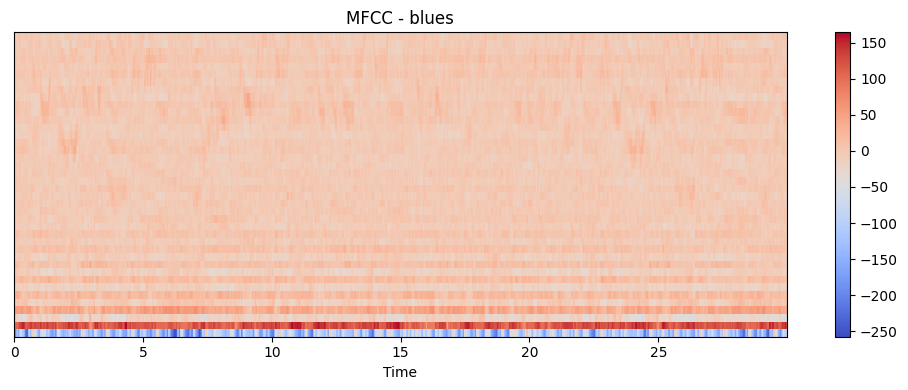

MFCC shape: (40, 1292)


In [4]:
sample_genre = GENRES[0]
sample_file = os.listdir(os.path.join(DATASET_PATH, sample_genre))[0]
sample_path = os.path.join(DATASET_PATH, sample_genre, sample_file)

audio, sr = librosa.load(sample_path, duration=30)
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title(f"MFCC - {sample_genre}")
plt.tight_layout()
plt.show()

print("MFCC shape:", mfcc.shape)


In [5]:
X = []
y = []

print("Starting MFCC feature extraction...")

for label, genre in enumerate(GENRES):
    genre_path = os.path.join(DATASET_PATH, genre)
    
    for file in tqdm(os.listdir(genre_path), desc=f"Processing {genre}"):
        file_path = os.path.join(genre_path, file)
        
        try:
            audio, sr = librosa.load(file_path, duration=30)
            mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
            
            mfcc_mean = np.mean(mfcc.T, axis=0)
            X.append(mfcc_mean)
            y.append(label)
        except Exception as e:
            print("Error processing:", file_path)

X = np.array(X)
y = np.array(y)

print("Feature extraction completed!")
print("X shape:", X.shape)
print("y shape:", y.shape)


Starting MFCC feature extraction...


Processing jazz:  52%|█████▏    | 52/100 [00:01<00:01, 28.31it/s]C:\Users\OM\AppData\Local\Temp\ipykernel_16444\2386093671.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, duration=30)
f:\RealTime_Music_Genre_Classification\.venv\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Processing jazz:  59%|█████▉    | 59/100 [00:02<00:01, 27.75it/s]

Error processing: F:\RealTime_Music_Genre_Classification\dataset\gtzan\genres_original\jazz\jazz.00054.wav


Processing rock: 100%|██████████| 100/100 [00:03<00:00, 28.89it/s]

Feature extraction completed!
X shape: (999, 40)
y shape: (999,)


In [6]:
np.save(FEATURES_PATH, X)
np.save(LABELS_PATH, y)

print("Features saved successfully!")
print("Saved at:", FEATURES_PATH)


Features saved successfully!
Saved at: F:\RealTime_Music_Genre_Classification\features\data.npy


In [7]:
X_loaded = np.load(FEATURES_PATH)
y_loaded = np.load(LABELS_PATH)

print("Loaded X shape:", X_loaded.shape)
print("Loaded y shape:", y_loaded.shape)


Loaded X shape: (999, 40)
Loaded y shape: (999,)
